In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

DATA_PATH = r"C:\Users\Papabizz\1. a Python\Ch 2\hospital_deterioration_hourly_panel.csv"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.head(3))


Shape: (417866, 28)
   patient_id  hour_from_admission  heart_rate  respiratory_rate  spo2_pct  \
0           1                    0       68.58             14.47     96.52   
1           1                    1       67.03             13.87     94.94   
2           1                    2       69.05             14.63     94.45   

   temperature_c  systolic_bp  diastolic_bp oxygen_device  oxygen_flow  ...  \
0          37.18       108.94         78.43          none          0.0  ...   
1          37.25       111.73         79.14          none          0.0  ...   
2          37.29       111.48         78.86          none          0.0  ...   

   age  gender  comorbidity_index  admission_type  baseline_risk_score  \
0   24       M                  2        Elective               0.2173   
1   24       M                  2        Elective               0.2173   
2   24       M                  2        Elective               0.2173   

   los_hours  deterioration_event  deterioration_with

In [2]:
print(df.shape)
df.info()

cat_cols = df.select_dtypes(include=["object","category","string"]).columns.tolist()
num_cols = df.select_dtypes(include=["number","bool","int64","float64"]).columns.tolist()
print("Categorical:", cat_cols)
print("Numeric count:", len(num_cols))

print("Total missing:", int(df.isna().sum().sum()))
print("Dup patient-hour:", df.duplicated(["patient_id","hour_from_admission"]).sum())

print("y rate (hourly):", df["deterioration_next_12h"].mean())
print("event rate (patient):", df.groupby("patient_id")["deterioration_event"].max().mean())


(417866, 28)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417866 entries, 0 to 417865
Data columns (total 28 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   patient_id                               417866 non-null  int64  
 1   hour_from_admission                      417866 non-null  int64  
 2   heart_rate                               417866 non-null  float64
 3   respiratory_rate                         417866 non-null  float64
 4   spo2_pct                                 417866 non-null  float64
 5   temperature_c                            417866 non-null  float64
 6   systolic_bp                              417866 non-null  float64
 7   diastolic_bp                             417866 non-null  float64
 8   oxygen_device                            417866 non-null  object 
 9   oxygen_flow                              417866 non-null  float64
 10  mobility_score     

In [3]:
df = df.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)

# Confirm monotonic hours within each patient
non_mono = df.groupby("patient_id")["hour_from_admission"] \
             .apply(lambda s: not s.is_monotonic_increasing).sum()
print("Patients with non-monotonic time:", int(non_mono))



Patients with non-monotonic time: 0


In [4]:
mask_event = df["deterioration_hour"] >= 0
df = df[~(mask_event & (df["hour_from_admission"] >= df["deterioration_hour"]))].copy()

print("After dropping post-event rows:", df.shape)


After dropping post-event rows: (382548, 28)


In [5]:
patient_table = (
    df.groupby("patient_id", as_index=False)
      .agg(deterioration_event=("deterioration_event", "max"))
)

patient_ids = patient_table["patient_id"].to_numpy()
patient_strata = patient_table["deterioration_event"].to_numpy()

print("Total patients:", len(patient_ids))
print("Patient event rate (for stratify):", patient_strata.mean())


Total patients: 10000
Patient event rate (for stratify): 0.1938


In [6]:
from sklearn.model_selection import train_test_split

trainval_ids, test_ids = train_test_split(
    patient_ids,
    test_size=0.20,
    random_state=42,
    stratify=patient_strata
)

trainval_ids = set(trainval_ids)
test_ids = set(test_ids)

print("Trainval patients:", len(trainval_ids))
print("Test patients:", len(test_ids))


Trainval patients: 8000
Test patients: 2000


In [7]:
df_trainval = df[df["patient_id"].isin(trainval_ids)].copy()
df_test     = df[df["patient_id"].isin(test_ids)].copy()

overlap = set(df_trainval["patient_id"].unique()) & set(df_test["patient_id"].unique())
print("Patient overlap trainval vs test:", len(overlap))

print("Trainval rows:", df_trainval.shape)
print("Test rows:", df_test.shape)

print("Hourly y rate trainval:", df_trainval["deterioration_next_12h"].mean())
print("Hourly y rate test:", df_test["deterioration_next_12h"].mean())


Patient overlap trainval vs test: 0
Trainval rows: (306760, 28)
Test rows: (75788, 28)
Hourly y rate trainval: 0.05895814317381667
Hourly y rate test: 0.059415738639362434


In [8]:
mandatory_drop = [
    "deterioration_next_12h",
    "deterioration_hour",
    "deterioration_event",
    "deterioration_within_12h_from_admission",
    "los_hours",
]
optional_drop_clean = ["nurse_alert", "sepsis_risk_score", "baseline_risk_score"]

def make_Xy_clean(d):
    y = d["deterioration_next_12h"].astype(int)
    X = d.drop(columns=mandatory_drop + optional_drop_clean)
    groups = X["patient_id"].copy()      # keep for group CV later
    X = X.drop(columns=["patient_id"])   # not a model feature
    return X, y, groups

X_trainval, y_trainval, g_trainval = make_Xy_clean(df_trainval)
X_test, y_test, g_test             = make_Xy_clean(df_test)

print("X_trainval:", X_trainval.shape, "X_test:", X_test.shape)
print("y rate trainval:", y_trainval.mean(), "y rate test:", y_test.mean())


X_trainval: (306760, 19) X_test: (75788, 19)
y rate trainval: 0.05895814317381667 y rate test: 0.059415738639362434


In [9]:
from sklearn.model_selection import StratifiedGroupKFold

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)


In [10]:
cat_cols = X_trainval.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols = [c for c in X_trainval.columns if c not in cat_cols]


print("Categorical columns:", cat_cols)
print("Numeric columns:", len(num_cols))


Categorical columns: ['oxygen_device', 'gender', 'admission_type']
Numeric columns: 16


LR FE

In [11]:
import numpy as np
import pandas as pd

vitals = [
    "heart_rate","respiratory_rate","spo2_pct","temperature_c",
    "systolic_bp","diastolic_bp","oxygen_flow","mobility_score"
]
labs = ["wbc_count","lactate","creatinine","crp_level","hemoglobin"]

def add_fe(d: pd.DataFrame) -> pd.DataFrame:
    d = d.copy()
    d = d.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)
    g = d.groupby("patient_id", sort=False)

    # Vitals: short-term trends
    for col in vitals:
        d[f"{col}_delta_1h"] = g[col].diff(1)
        d[f"{col}_mean_3h"]  = g[col].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)
        d[f"{col}_mean_6h"]  = g[col].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)
        d[f"{col}_min_6h"]   = g[col].rolling(6, min_periods=1).min().reset_index(level=0, drop=True)
        d[f"{col}_max_6h"]   = g[col].rolling(6, min_periods=1).max().reset_index(level=0, drop=True)

    # Labs: longer-term changes
    for col in labs:
        d[f"{col}_delta_6h"] = g[col].diff(6)
        d[f"{col}_mean_12h"] = g[col].rolling(12, min_periods=1).mean().reset_index(level=0, drop=True)

    # Clinical composites
    d["pulse_pressure"] = d["systolic_bp"] - d["diastolic_bp"]
    d["map"] = (d["systolic_bp"] + 2 * d["diastolic_bp"]) / 3.0
    d["shock_index"] = d["heart_rate"] / d["systolic_bp"].replace(0, np.nan)

    # Fill diffs (first rows per patient)
    diff_cols = [c for c in d.columns if c.endswith("_delta_1h") or c.endswith("_delta_6h")]
    d[diff_cols] = d[diff_cols].fillna(0.0)

    # Fill any remaining NaNs in engineered features (LR needs numeric stability)
    eng_cols = diff_cols + [c for c in d.columns if c.endswith("_mean_3h") or c.endswith("_mean_6h") or
                            c.endswith("_min_6h") or c.endswith("_max_6h") or c.endswith("_mean_12h")] + \
               ["pulse_pressure","map","shock_index"]
    # Only fill columns that exist (safe)
    eng_cols = [c for c in eng_cols if c in d.columns]
    d[eng_cols] = d[eng_cols].fillna(d[eng_cols].median(numeric_only=True))

    return d


In [12]:
df_trainval_fe = add_fe(df_trainval)
df_test_fe     = add_fe(df_test)

print("trainval:", df_trainval_fe.shape, "test:", df_test_fe.shape)


trainval: (306760, 81) test: (75788, 81)


In [13]:
# label + groups
y_trainval = df_trainval_fe["deterioration_next_12h"].astype(int)
y_test     = df_test_fe["deterioration_next_12h"].astype(int)

g_trainval = df_trainval_fe["patient_id"]
g_test     = df_test_fe["patient_id"]

leak_drop = [
    "deterioration_next_12h",
    "deterioration_hour",
    "deterioration_event",
    "deterioration_within_12h_from_admission",
    "los_hours",
]

X_trainval_fe = df_trainval_fe.drop(columns=[c for c in leak_drop + ["patient_id"] if c in df_trainval_fe.columns])
X_test_fe     = df_test_fe.drop(columns=[c for c in leak_drop + ["patient_id"] if c in df_test_fe.columns])

print("X_trainval_fe:", X_trainval_fe.shape, "X_test_fe:", X_test_fe.shape)


X_trainval_fe: (306760, 75) X_test_fe: (75788, 75)


In [14]:
cat_cols_fe = X_trainval_fe.select_dtypes(include=["object", "category", "string"]).columns.tolist()
num_cols_fe = [c for c in X_trainval_fe.columns if c not in cat_cols_fe]

print("Categorical:", cat_cols_fe)
print("Numeric:", len(num_cols_fe))


Categorical: ['oxygen_device', 'gender', 'admission_type']
Numeric: 72


In [15]:
print("X_trainval_fe shape:", X_trainval_fe.shape)
print("Any NaNs?", X_trainval_fe.isna().any().any())
print("Any inf?", np.isinf(X_trainval_fe.select_dtypes(include=[np.number]).to_numpy()).any())


X_trainval_fe shape: (306760, 75)
Any NaNs? False
Any inf? False


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Preprocess: scale numeric, one-hot categorical
preprocess_lr_fe = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_fe),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_fe),
    ],
    remainder="drop"
)

lr_fe = LogisticRegression(
    max_iter=2000,
    solver="lbfgs",
    class_weight="balanced",   # good default for AUPRC on imbalanced data
    n_jobs=None
)

lr_fe_clf = Pipeline(steps=[
    ("preprocess", preprocess_lr_fe),
    ("model", lr_fe)
])


In [17]:
import numpy as np
from sklearn.metrics import average_precision_score, roc_auc_score

lrfe_auprc, lrfe_auroc = [], []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval_fe, y_trainval, groups=g_trainval), 1):
    X_tr, y_tr = X_trainval_fe.iloc[tr_idx], y_trainval.iloc[tr_idx]
    X_va, y_va = X_trainval_fe.iloc[va_idx], y_trainval.iloc[va_idx]

    lr_fe_clf.fit(X_tr, y_tr)
    p_va = lr_fe_clf.predict_proba(X_va)[:, 1]

    auprc = average_precision_score(y_va, p_va)
    auroc = roc_auc_score(y_va, p_va)

    lrfe_auprc.append(auprc)
    lrfe_auroc.append(auroc)

    print(f"Fold {fold}: AUPRC={auprc:.4f}, AUROC={auroc:.4f}")

print("\nLogistic Regression (Feature Engineered) CV Summary")
print(f"AUPRC mean±std: {np.mean(lrfe_auprc):.4f} ± {np.std(lrfe_auprc):.4f}")
print(f"AUROC mean±std: {np.mean(lrfe_auroc):.4f} ± {np.std(lrfe_auroc):.4f}")


Fold 1: AUPRC=0.7563, AUROC=0.9658
Fold 2: AUPRC=0.7599, AUROC=0.9652
Fold 3: AUPRC=0.7079, AUROC=0.9620
Fold 4: AUPRC=0.7321, AUROC=0.9606
Fold 5: AUPRC=0.6846, AUROC=0.9616

Logistic Regression (Feature Engineered) CV Summary
AUPRC mean±std: 0.7282 ± 0.0287
AUROC mean±std: 0.9630 ± 0.0021


Catboost FE

In [25]:
import numpy as np
import pandas as pd

vitals = [
    "heart_rate","respiratory_rate","spo2_pct","temperature_c",
    "systolic_bp","diastolic_bp","oxygen_flow","mobility_score"
]
labs = ["wbc_count","lactate","creatinine","crp_level","hemoglobin"]

def add_fe(d: pd.DataFrame) -> pd.DataFrame:
    # Copy + ensure correct time order inside each patient
    d = d.copy()
    d = d.sort_values(["patient_id", "hour_from_admission"]).reset_index(drop=True)
    g = d.groupby("patient_id", sort=False)

    # Vitals: capture short-term change + recent level + recent extremes
    for col in vitals:
        d[f"{col}_delta_1h"] = g[col].diff(1)  # change in last hour (acute worsening/improvement)
        d[f"{col}_mean_3h"]  = g[col].rolling(3, min_periods=1).mean().reset_index(level=0, drop=True)  # smooth noise
        d[f"{col}_mean_6h"]  = g[col].rolling(6, min_periods=1).mean().reset_index(level=0, drop=True)  # sustained level
        d[f"{col}_min_6h"]   = g[col].rolling(6, min_periods=1).min().reset_index(level=0, drop=True)   # worst recent episode
        d[f"{col}_max_6h"]   = g[col].rolling(6, min_periods=1).max().reset_index(level=0, drop=True)   # highest recent stress

    # Labs: slower-moving → longer window features
    for col in labs:
        d[f"{col}_delta_6h"] = g[col].diff(6)  # meaningful lab change (not too noisy like 1h)
        d[f"{col}_mean_12h"] = g[col].rolling(12, min_periods=1).mean().reset_index(level=0, drop=True) 

    # Clinical composites: compress clinically meaningful interactions
    d["pulse_pressure"] = d["systolic_bp"] - d["diastolic_bp"]
    d["map"] = (d["systolic_bp"] + 2 * d["diastolic_bp"]) / 3.0
    d["shock_index"] = d["heart_rate"] / d["systolic_bp"].replace(0, np.nan)

    # Diffs create NaNs at the start of each patient → set to 0 (neutral no change yet)
    diff_cols = [c for c in d.columns if c.endswith("_delta_1h") or c.endswith("_delta_6h")]
    d[diff_cols] = d[diff_cols].fillna(0.0)

    # shock_index NaN only if SBP=0 → replace with median for stability
    if d["shock_index"].isna().any():
        d["shock_index"] = d["shock_index"].fillna(d["shock_index"].median())

    return d


In [26]:
df_trainval_fe = add_fe(df_trainval)  


In [27]:
# y and groups 
y_trainval = df_trainval_fe["deterioration_next_12h"].astype(int)
g_trainval = df_trainval_fe["patient_id"]

# Build X: drop ID + label 
drop_cols = ["patient_id", "deterioration_next_12h",
             "deterioration_hour", "deterioration_event",
             "deterioration_within_12h_from_admission", "los_hours"]

X_trainval_cb_fe = df_trainval_fe.drop(columns=[c for c in drop_cols if c in df_trainval_fe.columns])


In [28]:
cat_cols_cb = X_trainval_cb_fe.select_dtypes(include=["object", "category", "string"]).columns.tolist()
cat_features = [X_trainval_cb_fe.columns.get_loc(c) for c in cat_cols_cb]

print("Categorical cols:", cat_cols_cb)


Categorical cols: ['oxygen_device', 'gender', 'admission_type']


In [29]:
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
import numpy as np

cb = CatBoostClassifier(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

cb_fe_auprc, cb_fe_auroc = [], []

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_trainval_cb_fe, y_trainval, groups=g_trainval), 1):
    X_tr, y_tr = X_trainval_cb_fe.iloc[tr_idx], y_trainval.iloc[tr_idx]
    X_va, y_va = X_trainval_cb_fe.iloc[va_idx], y_trainval.iloc[va_idx]

    cb.fit(X_tr, y_tr, cat_features=cat_features)
    p_va = cb.predict_proba(X_va)[:, 1]

    cb_fe_auprc.append(average_precision_score(y_va, p_va))
    cb_fe_auroc.append(roc_auc_score(y_va, p_va))

    print(f"Fold {fold}: AUPRC={cb_fe_auprc[-1]:.4f}, AUROC={cb_fe_auroc[-1]:.4f}")

print("\nCatBoost FE CV Summary")
print(f"AUPRC mean±std: {np.mean(cb_fe_auprc):.4f} ± {np.std(cb_fe_auprc):.4f}")
print(f"AUROC mean±std: {np.mean(cb_fe_auroc):.4f} ± {np.std(cb_fe_auroc):.4f}")


Fold 1: AUPRC=0.7544, AUROC=0.9612
Fold 2: AUPRC=0.7731, AUROC=0.9617
Fold 3: AUPRC=0.7464, AUROC=0.9599
Fold 4: AUPRC=0.7547, AUROC=0.9573
Fold 5: AUPRC=0.7207, AUROC=0.9561

CatBoost FE CV Summary
AUPRC mean±std: 0.7499 ± 0.0170
AUROC mean±std: 0.9592 ± 0.0022


In [30]:
params = cb.get_params()
print("iterations:", params.get("iterations"))
print("depth:", params.get("depth"))
print("learning_rate:", params.get("learning_rate"))


iterations: 800
depth: 6
learning_rate: 0.05


Final Catboost train test fit

In [36]:
# Align test columns to exactly match what CatBoost was trained on
X_test_cb_fe = X_test_fe.reindex(columns=X_trainval_cb_fe.columns)

print("X_trainval_cb_fe:", X_trainval_cb_fe.shape)
print("X_test_cb_fe:", X_test_cb_fe.shape)

# Check missing columns (should be none after reindex, but NaNs may appear)
missing_in_test = X_trainval_cb_fe.columns.difference(X_test_fe.columns)
extra_in_test   = X_test_fe.columns.difference(X_trainval_cb_fe.columns)

print("Missing in test (were added as NaN):", list(missing_in_test))
print("Extra in test (ignored):", list(extra_in_test))
print("Any NaNs after alignment?:", X_test_cb_fe.isna().any().any())


X_trainval_cb_fe: (306760, 75)
X_test_cb_fe: (75788, 75)
Missing in test (were added as NaN): []
Extra in test (ignored): []
Any NaNs after alignment?: False


In [37]:
from catboost import CatBoostClassifier

cb_final = CatBoostClassifier(
    iterations=800,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=42,
    verbose=0
)

cb_final.fit(X_trainval_cb_fe, y_trainval, cat_features=cat_features)


In [38]:
p_train = cb_final.predict_proba(X_trainval_cb_fe)[:, 1]
p_test  = cb_final.predict_proba(X_test_cb_fe)[:, 1]


In [39]:
from sklearn.metrics import average_precision_score, roc_auc_score

print("Trainval AUPRC:", average_precision_score(y_trainval, p_train))
print("Trainval AUROC:", roc_auc_score(y_trainval, p_train))
print("Test AUPRC:", average_precision_score(y_test, p_test))
print("Test AUROC:", roc_auc_score(y_test, p_test))


Trainval AUPRC: 0.8782664898450094
Trainval AUROC: 0.9793354469153124
Test AUPRC: 0.756793467484059
Test AUROC: 0.9664708248789929


In [40]:
import numpy as np
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_trainval, p_train)

# thr length is len(prec)-1
f1s = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_i = int(np.argmax(f1s))
best_thr = float(thr[best_i])

print("Chosen threshold (from trainval, max F1):", best_thr)
print("Trainval Precision/Recall/F1 at chosen threshold:",
      float(prec[best_i]), float(rec[best_i]), float(f1s[best_i]))


Chosen threshold (from trainval, max F1): 0.3178381375243371
Trainval Precision/Recall/F1 at chosen threshold: 0.8325545631986752 0.778281543735486 0.8045037578939366


In [41]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

yhat_test = (p_test >= best_thr).astype(int)

print("\n=== Test metrics @ chosen threshold ===")
print("Accuracy:", accuracy_score(y_test, yhat_test))
print("Precision:", precision_score(y_test, yhat_test))
print("Recall:", recall_score(y_test, yhat_test))
print("F1:", f1_score(y_test, yhat_test))
print("Confusion matrix:\n", confusion_matrix(y_test, yhat_test))



=== Test metrics @ chosen threshold ===
Accuracy: 0.9667361587586425
Precision: 0.7328477443609023
Recall: 0.6926493448811903
F1: 0.7121817559082086
Confusion matrix:
 [[70148  1137]
 [ 1384  3119]]


In [42]:
targets = [0.80, 0.90]  
for target in targets:
    idx = np.where(rec[:-1] >= target)[0]
    if len(idx) == 0:
        print(f"\nNo threshold achieves recall >= {target} on trainval.")
        continue

    thr_target = float(thr[idx[-1]])  # higher threshold while keeping recall >= target
    yhat = (p_test >= thr_target).astype(int)

    print(f"\n=== Test @ trainval recall≥{target} threshold ({thr_target:.4f}) ===")
    print("Precision:", precision_score(y_test, yhat))
    print("Recall:", recall_score(y_test, yhat))
    print("F1:", f1_score(y_test, yhat))
    print("Confusion matrix:\n", confusion_matrix(y_test, yhat))



=== Test @ trainval recall≥0.8 threshold (0.2596) ===
Precision: 0.705276987081235
Recall: 0.7153009105041084
F1: 0.7102535832414554
Confusion matrix:
 [[69939  1346]
 [ 1282  3221]]

=== Test @ trainval recall≥0.9 threshold (0.0817) ===
Precision: 0.4866726182884836
Recall: 0.8474350433044637
F1: 0.6182760855476345
Confusion matrix:
 [[67260  4025]
 [  687  3816]]


False positives per 1000 non-events

In [43]:
# For each threshold case, plug in FP and TN from the confusion matrix
def fp_per_1000(TN, FP):
    return FP / (TN + FP) * 1000

print("F1-max FP/1000 non-events:", fp_per_1000(70148, 1137))
print("Recall≥0.8 FP/1000 non-events:", fp_per_1000(69939, 1346))
print("Recall≥0.9 FP/1000 non-events:", fp_per_1000(67260, 4025))


F1-max FP/1000 non-events: 15.95005961983587
Recall≥0.8 FP/1000 non-events: 18.881952724977204
Recall≥0.9 FP/1000 non-events: 56.46349161815249


Miss rate (FN rate among positives)

In [45]:
def fn_rate(FN, TP):
    return FN / (FN + TP)

print("F1-max miss rate:", fn_rate(1384, 3119))
print("Recall≥0.8 miss rate:", fn_rate(1282, 3221))
print("Recall≥0.9 miss rate:", fn_rate(687, 3816))


F1-max miss rate: 0.30735065511880966
Recall≥0.8 miss rate: 0.2846990894958916
Recall≥0.9 miss rate: 0.1525649566955363


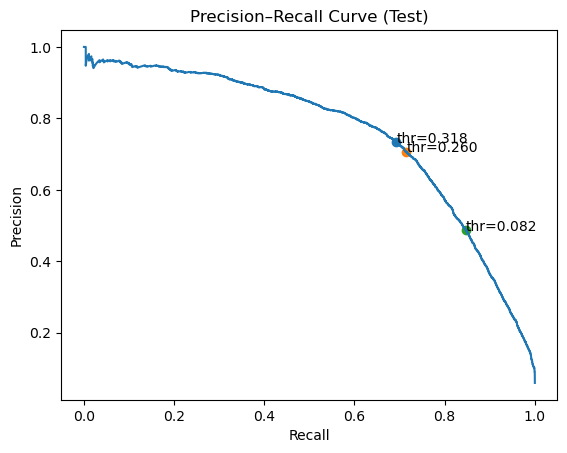

In [50]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, p_test)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test)")

# Mark your chosen thresholds (replace with your actual values)
for t in [best_thr, 0.2596, 0.0817]:
    # find closest threshold index
    if len(thr) > 0:
        i = (abs(thr - t)).argmin()
        plt.scatter(rec[i], prec[i])
        plt.text(rec[i], prec[i], f"thr={t:.3f}")

plt.show()


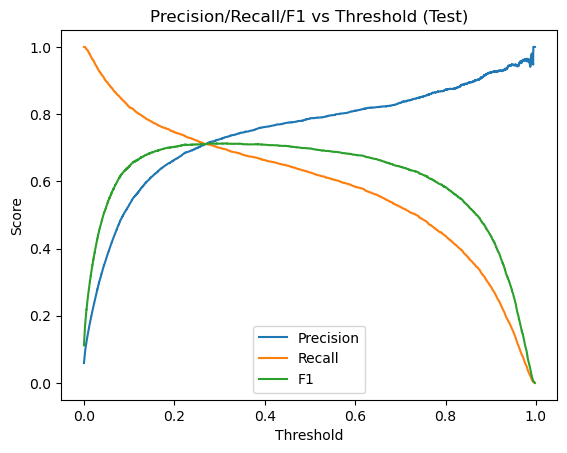

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

prec, rec, thr = precision_recall_curve(y_test, p_test)
f1 = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)

plt.figure()
plt.plot(thr, prec[:-1], label="Precision")
plt.plot(thr, rec[:-1], label="Recall")
plt.plot(thr, f1, label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision/Recall/F1 vs Threshold (Test)")
plt.legend()
plt.show()


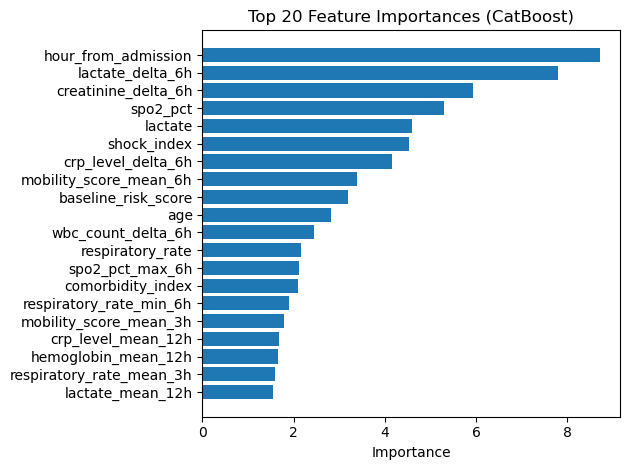

,feature,importance
0,hour_from_admission,8.716777
64,lactate_delta_6h,7.786181
66,creatinine_delta_6h,5.926231
3,spo2_pct,5.294145
12,lactate,4.588728
74,shock_index,4.518850
68,crp_level_delta_6h,4.150457
59,mobility_score_mean_6h,3.398070
21,baseline_risk_score,3.201486
17,age,2.813390


In [52]:
import pandas as pd
import matplotlib.pyplot as plt

importances = cb_final.get_feature_importance()
fi = pd.DataFrame({
    "feature": X_trainval_cb_fe.columns,
    "importance": importances
}).sort_values("importance", ascending=False).head(20)

plt.figure()
plt.barh(fi["feature"][::-1], fi["importance"][::-1])
plt.xlabel("Importance")
plt.title("Top 20 Feature Importances (CatBoost)")
plt.tight_layout()
plt.show()

fi
